## Домашка 1
#### *«Великаны — как луковицы. Лук многослоен! Я тоже! Слой за слоем. Ты усёк? Мы многослойные!» — Шрек*

Эта домашка про декомпозицию и срезы. За неё можно получить максимум 6 баллов.

**Дедлайны**  
Мягкий дедлайн: 20.09.2026 23:59 по МСК.   
Жесткий дедлайн: 27.09.2026 23:59 по МСК.  

Штраф за сдачу после мягкого дедлайна: –20% от набранного балла.   
После жесткого дедлайна работы не принимаются.   

**Правила сдачи**   
Задание выполняется самостоятельно, списывания не допускаются. При обнаружении одинаковых работ балл за задание анулируется у всех студентов, вне зависимости от того, кто у кого списал.    

**Использование ИИ**
- Использование генеративных моделей для написания кода допустимо при следующих условиях: сгенерированный фрагмент прочитан, адаптирован под условие задачи и данные, вы способны объяснить каждую его строку. Решение, полученное путем передачи модели формулировки задания целиком и прямого копирования ответа в ячейку ноутбука без содержательной переработки, оценивается в 0 баллов за это задание.
- Ответы на текстовые вопросы (описание поведения графика, интерпретация метрики, формулировка гипотез и т.п.) должны быть написаны вами самостоятельно в markdown-ячейках. Использование генеративных моделей для ответа на текстовые вопросы приводит к аннулированию всей работы, а не отдельного задания: интерпретация результатов — главный проверяемый в курсе навык, передача ее ИИ лишает нас возможности оценить, насколько хорошо вы усвоили материал.
- Если генеративная модель использовалась при решении, в конце ноутбука в отдельной markdown-ячейке укажите: номера заданий, при работе над которыми она применялась, использованную модель (с версией) и текст промтов. При обоснованном подозрении на использование ИИ, не отраженное в этом разделе, работа аннулируется целиком независимо от того, к какой части заданий относится подозрение.

#### **Как сдать домашку?**
1. Создайте закрытый репозиторий в личном гитхаб аккаунте для нашего предмета.
2. Пригласите в него своего ассистента — распределение по ассистентам и их гитхаб юзернеймы находятся в ведомости на листочке нашей дисциплины. Это можно сделать в настройках через раздел Collaborators and teams, уровень доступа ассистента должен быть Write.
3. Скачайте этот ноутбук и решите задания (локально или в Google Colab).
4. В репозитории предмета создайте ветку с номером ДЗ (например hw_1). В эту ветку запушьте .ipynb-файл с решением. Создайте pull request и добавьте в него ассистента как Reviewer. В этот же PR можете пушить сколько угодно изменений, будем смотреть на последнюю версию до наступления дедлайна.
5. Ссылку на PR продублируйте в форме сдачи (форма будет доступна на LMS Karpov Courses и в Телеграм-канале курса).

Пункты 1-2 проделываются один раз. Если вы прошли эти шаги при сдаче других домашек, повторять их не нужно, начинайте сразу с пункта 3.

**Внимание**: Если вы работаете в Google Colab, также скачивайте .ipynb файл и публикуйте его в репозитории. Ссылки на Colab к сдаче не принимаются.

Все датасеты, с которыми предлагается работать в домашних заданиях, взяты из открытых источников или сгенерированы. Любые паттерны, найденные вне заданной канвы решения, являются случайными и не несут в себе смысла или инсайта.

[Данные](https://github.com/brezhnevaan/hse_product_metrics_course/releases/download/datasets_for_hw/hw_1_data.zip)

### Case Study. Что-то пошло не так в маркетплейсе 🛒

**Легенда**  
Вы работаете продуктовым аналитиком в маркетплейсе. Ваша команда отвечает за функционал корзины — точки входа, дизайн и функционал самой корзины, путь пользователя с момента добавления товара в корзину и до оформления покупки.

Компания — стартап без системы автоматического мониторинга. Поэтому последние 14 дней, пока вы были в отпуске, никто не следил за метриками корзины.

Вы отлично отдохнули и в первый же день после каникул рвётесь в бой. Наливаете чашку кофе, открываете ноутбук и проверяете, что творилось в ваше отсутствие.

In [1]:
import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt

In [2]:
!wget -q https://github.com/brezhnevaan/hse_product_metrics_course/releases/download/datasets_for_hw/hw_1_data.zip
!unzip -q -o hw_1_data.zip

In [3]:
df = pd.read_parquet('data/hw_1_marketplace_data.parquet')

In [4]:
df.head()

,user_id,session_id,event_ts,platform,app_version,region,channel,category,event,product_id,price,quantity
0,30,1094418511,2025-04-01 19:49:57,Desktop,web,siberia,ads_search,None,search,NaN,NaN,NaN
1,30,1094418511,2025-04-01 20:02:23,Desktop,web,siberia,ads_search,electronics,view_item,123443.0,NaN,NaN
2,30,1094418511,2025-04-01 20:22:53,Desktop,web,siberia,ads_search,fashion,view_item,162950.0,NaN,NaN
3,30,1094418511,2025-04-01 20:40:57,Desktop,web,siberia,ads_search,home,view_item,199979.0,NaN,NaN
4,30,1094418511,2025-04-01 20:41:07,Desktop,web,siberia,ads_search,home,add_to_cart,199979.0,NaN,NaN


Описание данных

- user_id — уникальный идентификатор пользователя
- session_id — уникальный идентификатор сессии
- event_ts — таймстемп событий
- platform — платформа, с которой пришло событие
- app_version — версия приложения (существует только для iOS и Android, для остальных платформ приходят значения-заглушки)
- region — регион пользователя
- channel — канал, с которого пришел пользователь
- category — категория товаров, которой принадлежит ивент
- event — событие, совершенное пользователем
- product_id — идентификатор товара для событий над товарами
- price — цена товара, ивент приходит только для события покупки
- quantity — количество товаров, ивент приходит только для события покупки

#### **1. Детекция проблемы — 1 балл**

1) Посчитайте подневные конверсии: из просмотра в покупку, из просмотра в добавление в корзину, из добавления в корзину — в покупку.
2) Визуализируйте полученную динамику.
3) Опишите, что вы видите на графике: когда и в каких метриках началось падение? есть ли устойчивый тренд?

*К подсчёту конверсий можно подойти разными способами — считать их по событиям, сессиям или уникальным юзерам. В нашей задаче будем считать по сессиям.*

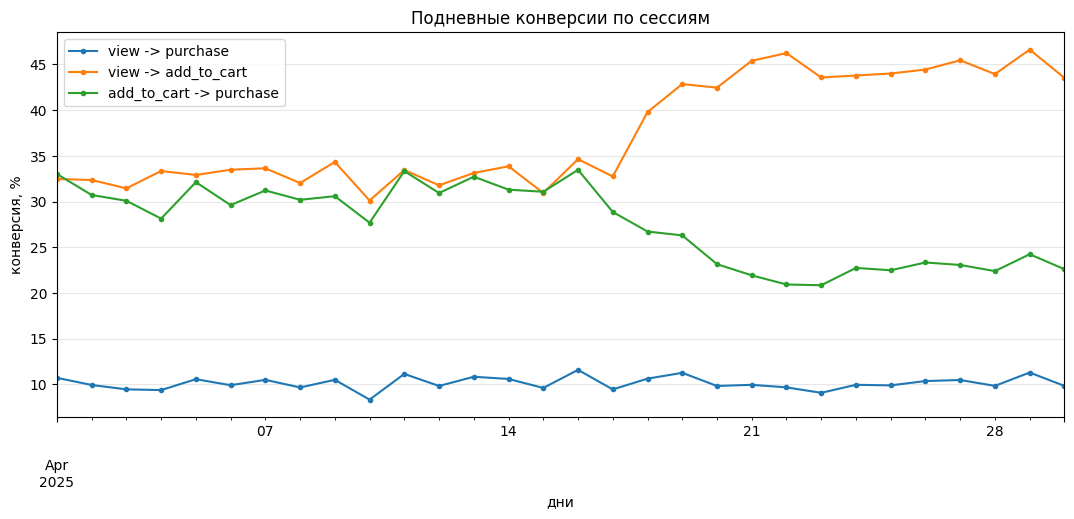

,view -> purchase,view -> add_to_cart,add_to_cart -> purchase
date,,,
2025-04-01,10.7,32.5,33.0
2025-04-02,9.9,32.4,30.7
2025-04-03,9.5,31.5,30.1
2025-04-04,9.4,33.3,28.1
2025-04-05,10.6,32.9,32.1
2025-04-06,9.9,33.5,29.6
2025-04-07,10.5,33.6,31.2
2025-04-08,9.7,32.0,30.2
2025-04-09,10.5,34.3,30.6


In [5]:
df['date'] = df['event_ts'].dt.normalize()

sessions = df.pivot_table(index='date', columns='event', values='session_id', aggfunc='nunique')

conv = pd.DataFrame({
    'view -> purchase': sessions['purchase'] / sessions['view_item'],
    'view -> add_to_cart': sessions['add_to_cart'] / sessions['view_item'],
    'add_to_cart -> purchase': sessions['purchase'] / sessions['add_to_cart'],
}) * 100

conv.plot(figsize=(13, 5), marker='o', ms=3)
plt.title('Подневные конверсии по сессиям')
plt.ylabel('конверсия, %')
plt.xlabel('дни')
plt.grid(alpha=0.3)
plt.show()

conv.round(1)

Точка слома - 18.04. До нее все три конверсии стоят ровно, после расходятся две: просмотр -> корзина уходит с ~33% до ~44%, корзина -> покупка с ~31% до ~22%. Обе за три-четыре дня выходят на новое плато и держатся до конца месяца. Третья конверсия, просмотр -> покупка, все это время лежит на ~10%. Если бы пользователи стали хуже покупать, просела бы и она


#### **2. Проверка абсолютных и средних значений — 1 балл**

1) Постройте графики дневной динамики абсолютных значений, из которых рассчитаны конверсии выше.
2) Рассчитайте и визуализируйте среднее число событий (именно событий, не сессий), из которых рассчитаны конверсии, на пользователя.
3) На каком этапе воронки появилась проблема?

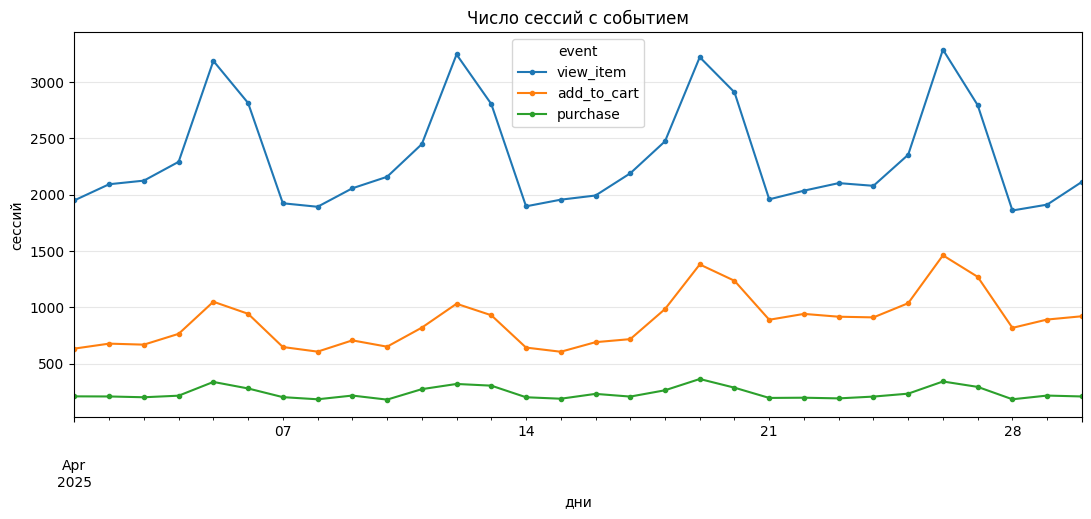

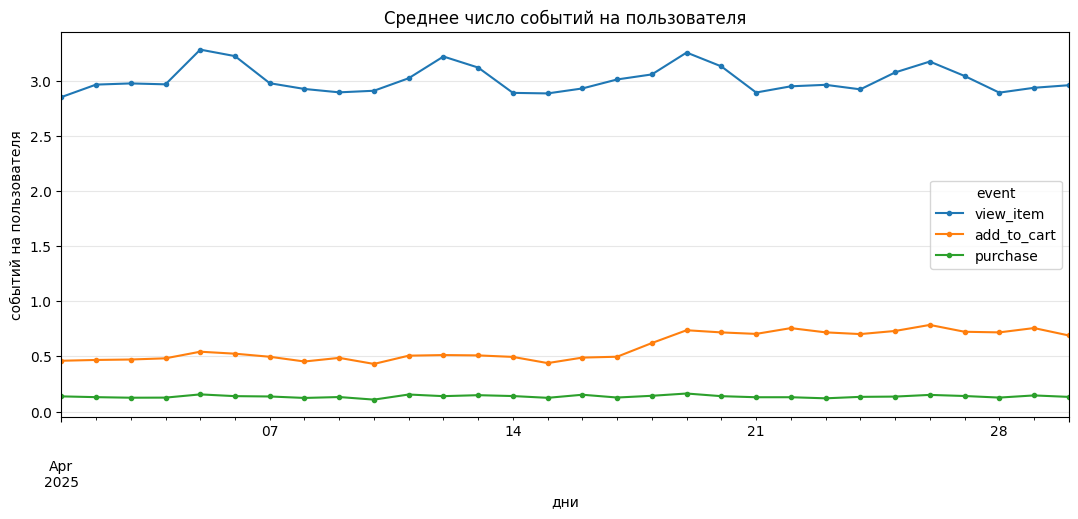

event,view_item,add_to_cart,purchase
date,,,
2025-04-01,2.85,0.46,0.14
2025-04-02,2.97,0.47,0.13
2025-04-03,2.98,0.47,0.13
2025-04-04,2.97,0.48,0.13
2025-04-05,3.28,0.54,0.16
2025-04-06,3.23,0.53,0.14
2025-04-07,2.98,0.50,0.14
2025-04-08,2.93,0.45,0.12
2025-04-09,2.90,0.49,0.13


In [6]:
funnel = ['view_item', 'add_to_cart', 'purchase']

sessions[funnel].plot(figsize=(13, 5), marker='o', ms=3)
plt.title('Число сессий с событием')
plt.ylabel('сессий')
plt.xlabel('дни')
plt.grid(alpha=0.3)
plt.show()

event_counts = df.pivot_table(index='date', columns='event', values='user_id', aggfunc='size')
dau = df.groupby('date')['user_id'].nunique()
per_user = event_counts[funnel].div(dau, axis=0)

per_user.plot(figsize=(13, 5), marker='o', ms=3)
plt.title('Среднее число событий на пользователя')
plt.ylabel('событий на пользователя')
plt.xlabel('дни')
plt.grid(alpha=0.3)
plt.show()

per_user.round(2)

Сессий с просмотрами и покупками столько же, сколько было, а сессий с add_to_cart с 18.04 заметно больше. view_item ~3.0 и purchase ~0.13 не сдвинулись, add_to_cart вырос с ~0.49 до ~0.72, в полтора раза. Проблема на одном шаге воронки, на добавлении в корзину. Конверсия корзина -> покупка упала механически: числитель на месте, а знаменатель стал больше. То есть деньги мы не теряем, но метрика перестала что-либо измерять

#### **3. Базовые срезы — 1 балл**
1. Постройте динамику события, среднее значение которого подскочило, в разрезе:
- платформ,
- регионов,
- источников трафика,
- категорий товаров.

2. Есть ли выделяющийся срез?

*В этом пункте в качестве события продолжаем смотреть метрику среднего на пользователя*

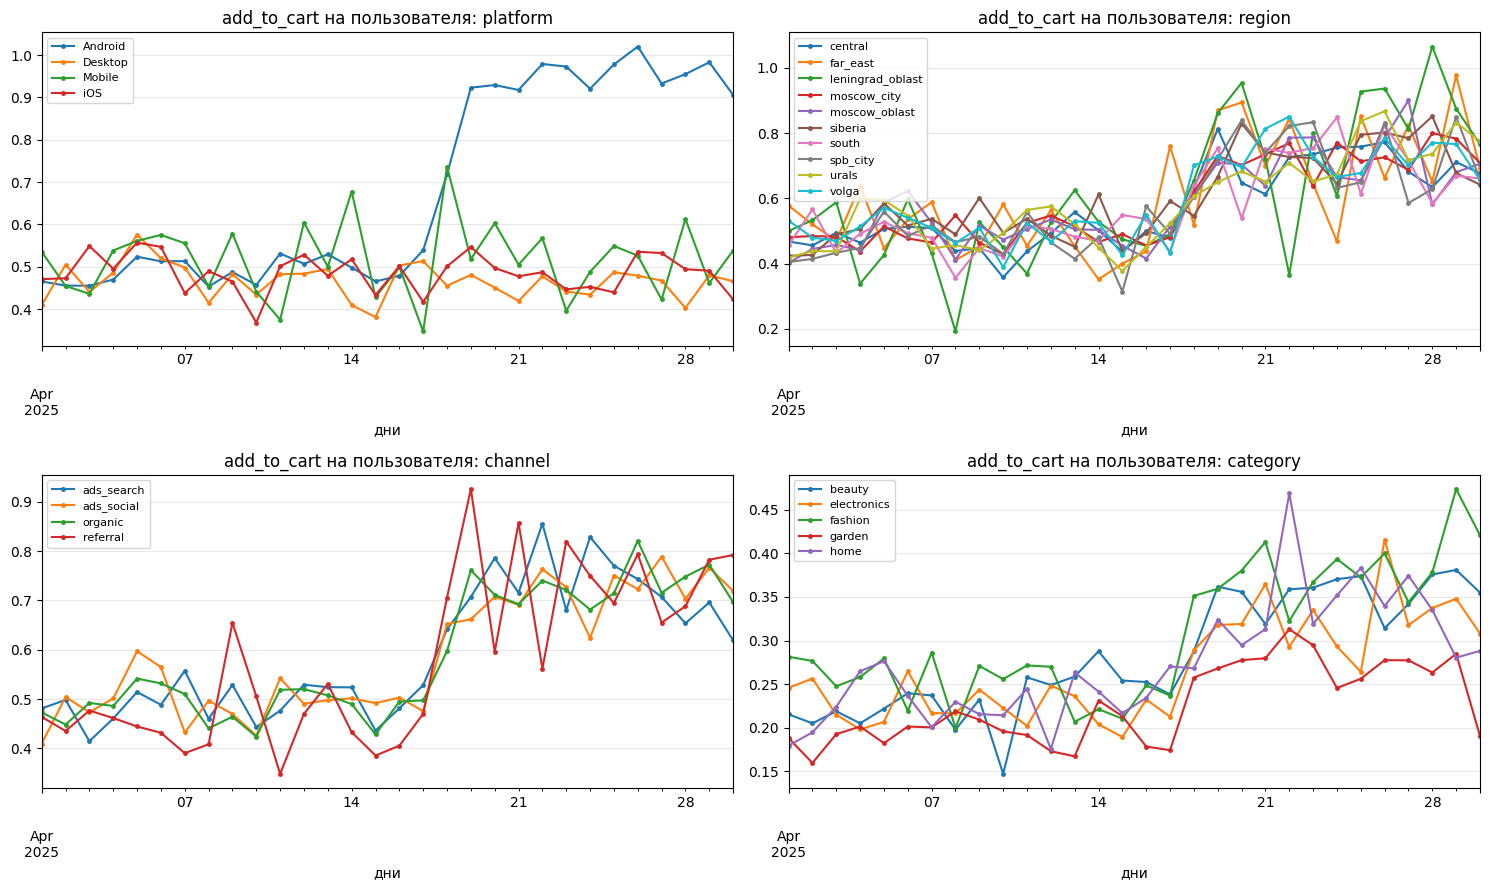

,до 18.04,с 21.04,раз
platform,,,
Android,0.49,0.96,1.95
Desktop,0.47,0.46,0.96
Mobile,0.50,0.51,1.01
iOS,0.48,0.48,0.99


In [7]:
def events_per_user(data, event, dim):
    cnt = data[data['event'] == event].pivot_table(index='date', columns=dim, values='user_id', aggfunc='size')
    users = data.pivot_table(index='date', columns=dim, values='user_id', aggfunc='nunique')
    return (cnt / users).dropna(axis=1, how='all')

dims = ['platform', 'region', 'channel', 'category']

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
for dim, ax in zip(dims, axes.flat):
    events_per_user(df, 'add_to_cart', dim).plot(ax=ax, marker='o', ms=2.5)
    ax.set_title(f'add_to_cart на пользователя: {dim}')
    ax.set_xlabel('дни')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

atc = events_per_user(df, 'add_to_cart', 'platform')
levels = pd.DataFrame({'до 18.04': atc.loc[:'2025-04-17'].mean(), 'с 21.04': atc.loc['2025-04-21':].mean()})
levels['раз'] = levels['с 21.04'] / levels['до 18.04']
levels.round(2)

Есть один - Android: 0.49 -> 0.96 добавлений на пользователя, почти вдвое больше. Desktop, Mobile и iOS не изменились

Регионы, каналы и категории растут одинаково - везде рост в 1.4-1.6 раза. Настоящая причина дает перекос внутри среза, а не ровную прибавку по всем значениям сразу. Android есть в каждом регионе и в каждом канале, поэтому одинаково подсвечивает их все

#### **4. Детальные срезы — 1 балл**
1. Постройте динамику события для iOS и Android с разложением по версиям приложения.
2. Помогло ли это локализовать проблему?

*В этом пункте в качестве события продолжаем смотреть метрику среднего на пользователя*

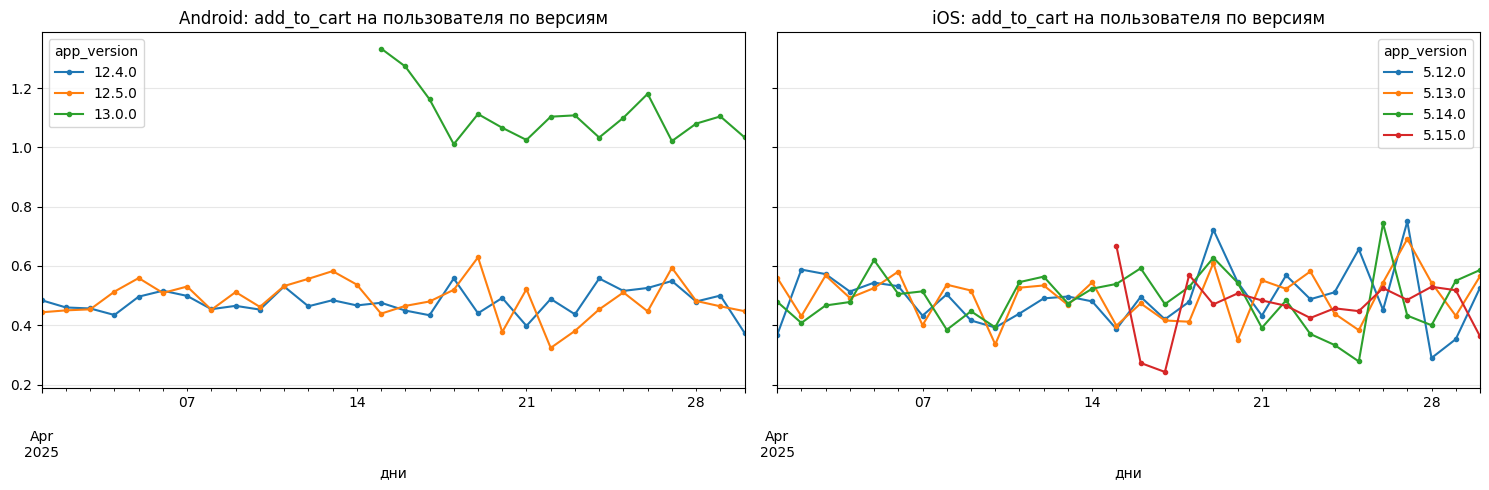

app_version,12.4.0,12.5.0,13.0.0
date,,,
2025-04-14,55.3,44.7,NaN
2025-04-15,54.8,44.5,0.7
2025-04-16,53.4,43.9,2.7
2025-04-17,47.7,40.4,11.9
2025-04-18,33.7,28.3,37.9
2025-04-19,17.4,14.9,67.7
2025-04-20,11.4,10.3,78.3
2025-04-21,10.5,8.2,81.3
2025-04-22,10.2,7.9,81.9


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for platform, ax in zip(['Android', 'iOS'], axes):
    events_per_user(df[df['platform'] == platform], 'add_to_cart', 'app_version').plot(ax=ax, marker='o', ms=3)
    ax.set_title(f'{platform}: add_to_cart на пользователя по версиям')
    ax.set_xlabel('дни')
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

android_users = df[df['platform'] == 'Android'].pivot_table(
    index='date', columns='app_version', values='user_id', aggfunc='nunique')

(android_users.div(android_users.sum(axis=1), axis=0) * 100).round(1).loc['2025-04-14':'2025-04-24']

Да, проблема локализована до одной сборки. На Android выбивается 13.0.0: она появляется в данных 15.04 и сразу живет на 1.0-1.3 добавления на пользователя против ~0.48 на 12.4.0 и 12.5.0. Старые версии после релиза не изменились

у iOS 15.04 вышла своя новая версия 5.15.0, она ничем не отличается от 5.12-5.14

По датам видно, что 15.04 на 13.0.0 было меньше 1% андроид-аудитории, 17.04 - 12%, 18.04 - уже 38%, к 20.04 - около 80%. Общая метрика ломается, когда новая версия набирает вес

#### **5. Поиск причин — 1 балл**
1. Для проблемной платформы постройте динамику ВСЕХ событий в разрезе версий приложения.
2. Сформулируйте гипотезу, что именно могло пойти не так в новом релизе? Может быть, пользователи стали заменять один функционал другим?

*В этом пункте в качестве событий продолжаем смотреть метрику среднего на пользователя*

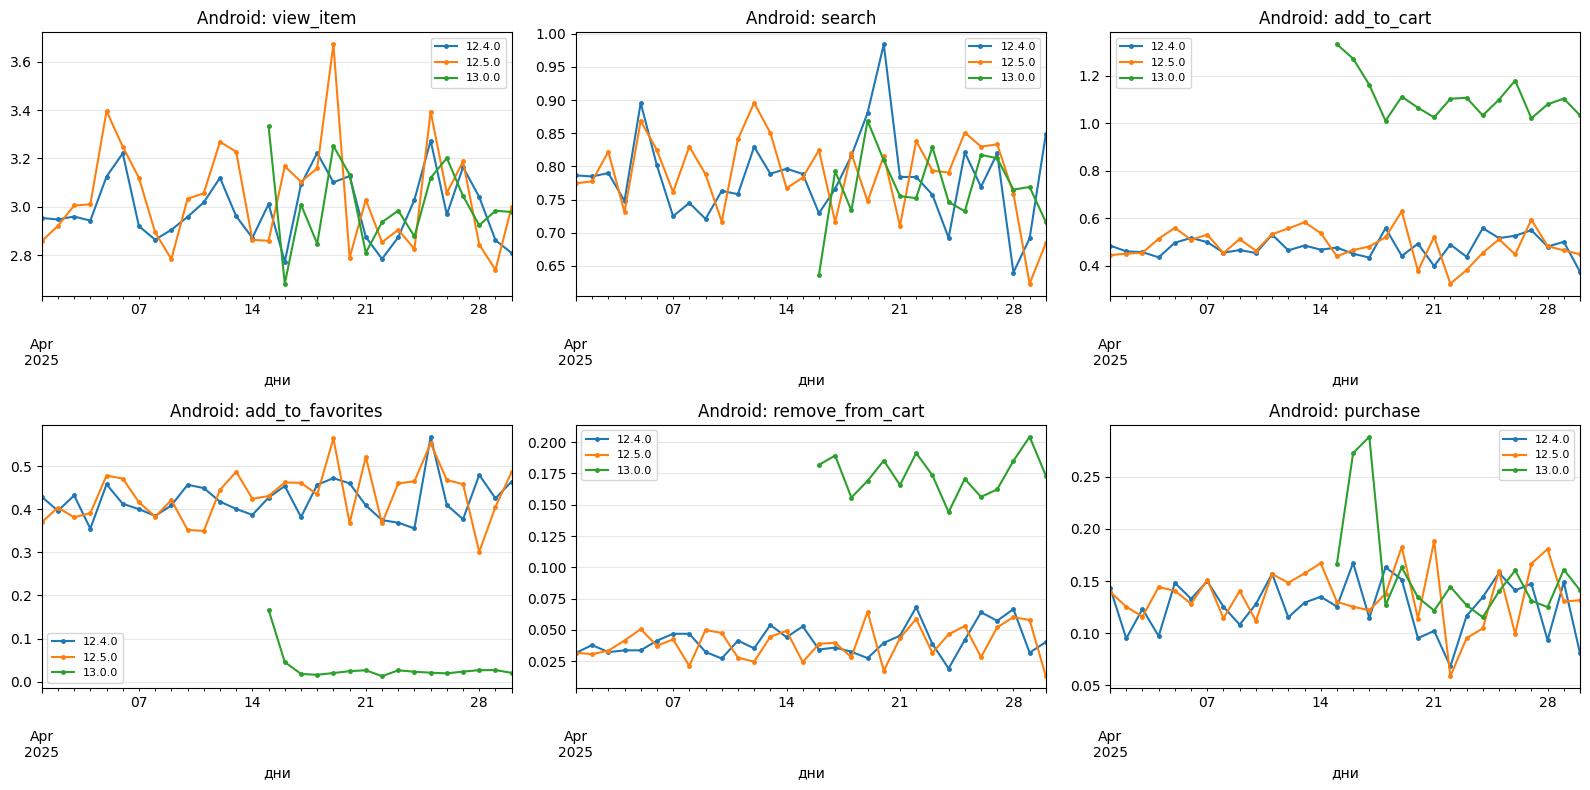

app_version,12.4.0,12.5.0,13.0.0
view_item,2.968,2.983,2.986
search,0.761,0.771,0.770
add_to_cart,0.483,0.462,1.079
add_to_favorites,0.423,0.449,0.023
remove_from_cart,0.047,0.045,0.173
purchase,0.119,0.132,0.137


In [9]:
android = df[df['platform'] == 'Android'].copy()
all_events = ['view_item', 'search', 'add_to_cart', 'add_to_favorites', 'remove_from_cart', 'purchase']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for event, ax in zip(all_events, axes.flat):
    events_per_user(android, event, 'app_version').plot(ax=ax, marker='o', ms=2.5)
    ax.set_title(f'Android: {event}')
    ax.set_xlabel('дни')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

pd.DataFrame({e: events_per_user(android, e, 'app_version').loc['2025-04-21':].mean()
              for e in all_events}).T.round(3)

Нужно посмотреть, событие задваивается или нет. Если бы add_to_cart просто отправлялся дважды за один тап, это был бы баг трекинга и тогда внутри сессии были бы повторные добавления одного и того же товара

Также нужно проверить, на 13.0.0 сидят другие люди или нет. Первыми обновляются обычно самые активные, так что разница между версиями может быть разницей аудиторий, а не эффектом релиза

In [12]:
late = android[android['date'] >= '2025-04-21']
cart = late[late['event'] == 'add_to_cart'].copy()
cart['dup'] = cart.duplicated(['session_id', 'product_id'])

items = cart.drop_duplicates(['user_id', 'product_id']).groupby('app_version').size()
users = late.groupby('app_version')['user_id'].nunique()

print('доля повторов среди add_to_cart:')
print(cart.groupby('app_version')['dup'].mean().round(3))
print()
print('уникальных товаров в корзине на пользователя:')
print((items / users).round(2))
print()

fav = android[(android['app_version'] == '13.0.0') & (android['event'] == 'add_to_favorites')]
print('add_to_favorites на 13.0.0:', len(fav), 'событий от', fav['user_id'].nunique(), 'пользователей')

доля повторов среди add_to_cart:
app_version
12.4.0    0.0
12.5.0    0.0
13.0.0    0.0
Name: dup, dtype: float64

уникальных товаров в корзине на пользователя:
app_version
12.4.0    0.52
12.5.0    0.50
13.0.0    1.40
dtype: float64

add_to_favorites на 13.0.0: 212 событий от 210 пользователей


In [13]:
android['ver'] = android['app_version'].where(android['app_version'] == '13.0.0', '12.x')

versions = android.groupby('user_id')['ver'].nunique()
switched = versions[versions == 2].index
same = android[android['user_id'].isin(switched)]
print('пользователей, побывавших и на 12.x, и на 13.0.0:', len(switched))

user_days = same.pivot_table(index=['ver', 'user_id', 'date'], columns='event',
                             values='event_ts', aggfunc='size', fill_value=0)

user_days.groupby('ver').mean()[['add_to_cart', 'add_to_favorites', 'remove_from_cart', 'purchase']].round(3)

пользователей, побывавших и на 12.x, и на 13.0.0: 5243


event,add_to_cart,add_to_favorites,remove_from_cart,purchase
ver,,,,
12.x,0.493,0.426,0.040,0.136
13.0.0,1.091,0.022,0.171,0.144


**Что изменилось в 13.0.0**

Среднее число событий на пользователя, период с 21.04:

| событие | 12.4.0 | 12.5.0 | 13.0.0 |
|---|---|---|---|
| view_item | 2.97 | 2.98 | 2.99 |
| search | 0.76 | 0.77 | 0.77 |
| purchase | 0.12 | 0.13 | 0.14 |
| add_to_cart | 0.48 | 0.46 | **1.08** |
| add_to_favorites | 0.42 | 0.45 | **0.02** |
| remove_from_cart | 0.047 | 0.045 | **0.17** |

Половина событий релиза не заметила. Смотрят, ищут и покупают столько же, но сдвинулись три показателя: избранное схлопнулось почти в ноль, корзина выросла вдвое, удаления из корзины - вчетверо

Гипотеза в следующем: в 13.0.0 отвалилась точка входа в избранное, кнопка пропала с карточки, не срабатывает или подменена на "в корзину". Пользователь не изменился и по-прежнему хочет отложить товар, но единственная оставшаяся кнопка кладет его в корзину


#### **6. Новости для команды — 1 балл**

На основе проведённого расследования подготовьте сообщение для команды о том, что именно пошло не так.

Всем привет. Пока никто не смотрел на метрики, у нас сломалось избранное на Android. Выручка не пострадала, но конверсия корзина -> покупка теперь врет.

Коротко, что произошло:

- с 18.04 конверсия корзина -> покупка упала с ~31% до ~22% и держится
- покупок при этом не стало меньше: просмотр -> покупка стоит на ~10%, покупки и просмотры на пользователя не изменились
- упала она из-за знаменателя - добавлений в корзину на пользователя стало в полтора раза больше
- рост целиком с Android, с версии 13.0.0. iOS, Desktop и Mobile чистые. Релиз катился с 15.04 и к 20.04 забрал ~80% андроид-аудитории, поэтому на общих графиках слом виден с 18.04, а не с 15.04
- на 13.0.0 против 12.x: add_to_cart 0.48 -> 1.08, add_to_favorites 0.43 -> 0.02, remove_from_cart 0.045 -> 0.17. Просмотры, поиск и покупки не изменились
- проверила, что дело не в двойной отправке события и не в том, что на новой версии другие люди: повторов (сессия, товар) нет, а у одних и тех же пользователей после обновления корзина выросла вдвое и ровно тогда же обнулилось избранное

Похоже, в 13.0.0 кнопка избранного пропала, не работает или заменилась на "в корзину". Люди ведут себя как раньше, но откладывают товар теперь в корзину, а потом ее разгребают

Думаю, что мобильной команде нужно посмотреть на 13.0.0 карточку товара: есть ли кнопка избранного и уходит ли add_to_favorites. Единичные события все же приходят, так что, скорее всего, отвалилась одна точка входа, а не вся фича
